In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from BitstreamDiffusion.utils.text_decode import decode_bitstreams_for_eval
from pi_solvers import sde_lib, solver_lib, utils
from BitstreamDiffusion.evaluation.utils import load_config, unwrap_all, load_checkpoint
from BitstreamDiffusion.models import create_model
from BitstreamDiffusion.utils import text_decode, ema

torch.manual_seed(42)

In [2]:
cfg = "../BitstreamDiffusion/configs/lm1b/continuous/eval/rate_eval_seeds.py"

In [3]:
cfg = load_config(cfg)

In [4]:
model = create_model(cfg).to("cuda")
ema_ = ema.EMA(unwrap_all(model), decay=0.0)
load_checkpoint(model, ema_, Path("../BitstreamDiffusion/" + cfg.evaluation.checkpoint_path), "cuda", apply_ema=True)

model.eval()

✅ Instantiating SequenceVDTContinuousModel for framework: 'continuous_score'
Loading checkpoint: ..\BitstreamDiffusion\runs\paper\unconditional_text\lm1b\continuous_rate_raw_binary_bits_1M_edm_weighting\checkpoints\step=001000000.pt
⚠️ No EMA found in checkpoint, using raw weights.


SequenceVDTContinuousModel(
  (cont_input_proj): Linear(in_features=1, out_features=64, bias=True)
  (time_fn): _SinTimeSigma()
  (time_proj): Linear(in_features=768, out_features=768, bias=False)
  (time_cond): Linear(in_features=768, out_features=768, bias=True)
  (patch_proj): Linear(in_features=3015, out_features=768, bias=True)
  (unpatch_proj_content): Linear(in_features=768, out_features=960, bias=True)
  (blocks): ModuleList(
    (0-11): 12 x PreNormBlockAda(
      (attn): SelfAttention(
        (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (rope): RotaryEmbedding()
      )
      (ff): SwiGLU(
        (Wa): Linear(in_features=768, out_features=2048, bias=True)
        (Wb): Linear(in_features=768, out_features=2048, bias=True)
        (Wo): Linear(in_features=2048, out_features=768, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (drop): Dropout(p=0.1, inp

In [61]:
entropy_pi = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_pdf.pt")

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0009, 0.0014, 0.0022, 0.0032,
        0.0046, 0.0061, 0.0080, 0.0103, 0.0128, 0.0157, 0.0188, 0.0220, 0.0254,
        0.0286, 0.0317, 0.0344, 0.0365, 0.0380, 0.0389, 0.0391, 0.0387, 0.0379,
        0.0367, 0.0353, 0.0336, 0.0319, 0.0301, 0.0283, 0.0265, 0.0247, 0.0231,
        0.0215, 0.0199, 0.0185, 0.0171, 0.0158, 0.0146, 0.0135, 0.0125, 0.0115,
        0.0106, 0.0098, 0.0091, 0.0083, 0.0077, 0.0071, 0.0065, 0.0060, 0.0055,
        0.0051, 0.0047, 0.0043, 0.0040, 0.0037, 0.0034, 0.0031, 0.0029, 0.0026,
        0.0024, 0.0022, 0.0021, 0.0019, 

In [60]:
torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt")

tensor([2.0845e-03, 2.2644e-03, 2.4599e-03, 2.6722e-03, 2.9028e-03, 3.1534e-03,
        3.4255e-03, 3.7212e-03, 4.0424e-03, 4.3913e-03, 4.7703e-03, 5.1820e-03,
        5.6292e-03, 6.1151e-03, 6.6429e-03, 7.2162e-03, 7.8391e-03, 8.5157e-03,
        9.2506e-03, 1.0049e-02, 1.0916e-02, 1.1859e-02, 1.2882e-02, 1.3994e-02,
        1.5202e-02, 1.6514e-02, 1.7939e-02, 1.9487e-02, 2.1169e-02, 2.2996e-02,
        2.4981e-02, 2.7137e-02, 2.9480e-02, 3.2024e-02, 3.4788e-02, 3.7790e-02,
        4.1052e-02, 4.4595e-02, 4.8444e-02, 5.2626e-02, 5.7168e-02, 6.2102e-02,
        6.7462e-02, 7.3284e-02, 7.9609e-02, 8.6481e-02, 9.3945e-02, 1.0205e-01,
        1.1086e-01, 1.2043e-01, 1.3082e-01, 1.4212e-01, 1.5438e-01, 1.6771e-01,
        1.8218e-01, 1.9790e-01, 2.1498e-01, 2.3354e-01, 2.5370e-01, 2.7559e-01,
        2.9938e-01, 3.2522e-01, 3.5329e-01, 3.8378e-01, 4.1690e-01, 4.5289e-01,
        4.9198e-01, 5.3444e-01, 5.8057e-01, 6.3067e-01, 6.8511e-01, 7.4424e-01,
        8.0847e-01, 8.7825e-01, 9.5405e-

In [54]:
entropy = torch.cat([torch.tensor([0.002]), torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt"), torch.tensor([80])]).flip(dims=(0,))

In [55]:
torch.log(entropy)[1:] - torch.log(entropy)[:-1]

tensor([-0.0414, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828, -0.0828,
        -0.0828, -0.0828, -0.0828, -0.08

In [114]:
C = 30
sigmoid = torch.nn.Sigmoid()

class BitstreamDiffusionModel:
    
    def __init__(self, sc_enabled: bool = True):
        self._sc_enabled = sc_enabled
        self._x0_hat = None

    def __call__(self, x, t, _):
        r = model(x, t.reshape(-1), self._x0_hat)[:, :, -1]
        l = r + torch.clamp((x - 0.5) / t ** 2, -C, C)
        # Returned values are probs, use these for self conditioning
        p = sigmoid(l)
        if self._sc_enabled:
            self._x0_hat = p.clone()
        return p

n = 128
model_func = BitstreamDiffusionModel(sc_enabled=True)

In [115]:
noise = torch.randn((16, 1920)).to("cuda") * 80
sigma = torch.ones(16).to("cuda") * 80

In [116]:
# sde = sde_lib.EDMSDE().to("cuda").get_reverse_sde(model_func, ode_threshold=0).to("cuda")
sde = sde_lib.construct_churn_sde(model_func, n, S_max=100, S_min=0).to("cuda")
discretisation = solver_lib.get_edm_schedule(n).to("cuda")

In [117]:
# solver = solver_lib.EDMSolver(sde, discretisation, model_func, S_churn=40, S_noise=1.003, S_max=50, S_min=0.05).to("cuda")
solver = solver_lib.EulerMarayumaSolver(sde, discretisation).to("cuda")
with torch.no_grad():
    x_em = solver.solve(noise.clone())

In [118]:
x_em

tensor([[-1.1568e-03,  9.9965e-01,  1.0013e+00,  ...,  2.1588e-03,
          1.0009e+00,  1.0006e+00],
        [ 1.0034e+00,  2.7630e-04, -2.3687e-03,  ...,  9.9869e-01,
          9.9891e-01,  9.2336e-04],
        [-1.5536e-03,  2.3348e-03,  1.9320e-03,  ...,  1.5248e-03,
          9.9996e-01,  3.2769e-03],
        ...,
        [ 1.9981e-03,  3.9285e-03,  3.6396e-04,  ...,  9.9989e-01,
          9.9995e-01,  1.0003e+00],
        [-4.1401e-03,  2.5563e-03,  1.0000e+00,  ...,  1.4794e-03,
          1.0002e+00, -4.3966e-03],
        [ 1.5451e-03,  1.9830e-03,  1.0024e+00,  ...,  9.9886e-01,
          1.0024e+00,  9.9567e-01]], device='cuda:0')

In [119]:
decode_bitstreams_for_eval(cfg, x_em)

["thy fujian pneumonias even if disease association fame. [SEP] or on thinking that policy will force you to suspiciously your lifestyle ; california is just becoming effective? [SEP] and for us this is no one to look to settle, and you certainlyuled stops follow that the democratic order have taken care of the exhaustion and affection. [SEP] the message took into toll as industry executives, maverick restaurant members, ledzzometry 310 and neighbour wnba lee refused pre - order visits to barely aquatic them in dress deciding sapry, and their staff on the kennash academy ' anti comet lingo anthem triggered some faction verdictets that his claim would be hollywood ' s essential",
 'minimize into the release of former scotland beverly williamson after sir ian terrell upstairs a deadlock of decades church members as linings. [SEP] in their final two games, the rangers remain 0 - 1 behind on the bowl side. [SEP] banks are bolstering supplies to other lending, but estimates the bonds could 

In [11]:
sigmas = []
hs = []
sigmas_std = []
trajectories = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    hs.append(torch.mean(h).cpu())
    sigmas_std.append(torch.std(t).cpu())
    trajectories.append(t[0:2].clone())

In [85]:
sigmas = [torch.tensor([80])]
hs = []
sigmas_std = [0]
trajectories = []

sde.reset()

pi_solver = solver_lib.PISolver(
    sde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.06,
    tau_r=2.2,
    alpha=0.9,
    h_start=20,
    max_decrease=0.02,
    max_increase=5,
    interval=(80, 0),
    abs_error=False,
    batch_norm=False
).to("cuda")
with torch.no_grad():
    x_pi = pi_solver.solve(noise.clone(), callback=pi_callback)

sigma = 60.0 h = -12.551570892333984 error = 0.173099085688591
sigma = 47.448429107666016 h = -9.346488952636719 error = 0.1510322093963623
sigma = 38.1019401550293 h = -6.98164701461792 error = 0.14481040835380554
sigma = 31.12029266357422 h = -5.3001179695129395 error = 0.13763010501861572
sigma = 25.820175170898438 h = -4.076113224029541 error = 0.13155531883239746
sigma = 21.744062423706055 h = -3.184253215789795 error = 0.12508688867092133
sigma = 18.5598087310791 h = -2.5073177814483643 error = 0.12109661847352982
sigma = 16.052492141723633 h = -2.0008347034454346 error = 0.11617705225944519
sigma = 14.051656723022461 h = -1.620189905166626 error = 0.11085487902164459
sigma = 12.431467056274414 h = -1.3228098154067993 error = 0.1073254644870758
sigma = 11.108657836914062 h = -1.0945487022399902 error = 0.10296458750963211
sigma = 10.014108657836914 h = -0.9130212664604187 error = 0.09986431896686554
sigma = 9.10108757019043 h = -0.7715089321136475 error = 0.0959622859954834
sigma

In [109]:
pi = (torch.tensor(sigmas[:-2]) / torch.abs(torch.tensor(hs[:-1]))) / (sde.nfe / 16)
pi = pi / torch.sum(pi) * 5

In [110]:
edm_pi = discretisation[:-1] / (discretisation[:-1] - discretisation[1:]) / (256)
edm_pi = edm_pi / torch.sum(edm_pi)

In [111]:
entropy_pi = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_pdf.pt")
sigma_entropy = torch.load("../BitstreamDiffusion/assets/entropy_tables/lm1b/entropy_sigmas.pt").flip(dims=(0,))

In [112]:
entropy_pi.sum()

tensor(1.0000)

Text(0, 0.5, '$\\pi_{\\alpha}$')

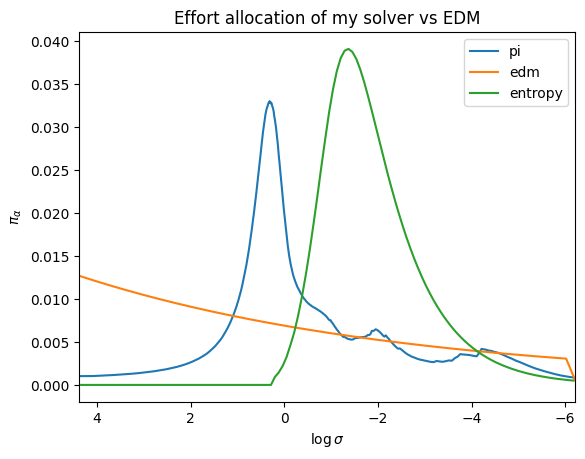

In [113]:
plt.title(r"Effort allocation of my solver vs EDM")
import math

plt.plot(torch.log(torch.tensor(sigmas[:-2])).cpu(), pi, label="pi")
plt.plot(torch.log(discretisation[:-1]).cpu(), edm_pi.cpu(), label="edm")
plt.plot(torch.log(sigma_entropy), entropy_pi.cpu(), label="entropy")

plt.legend()
plt.xlim(math.log(80), math.log(0.002))
plt.xlabel(r"$\log \sigma$")
plt.ylabel(r"$\pi_{\alpha}$")

In [103]:
decode_bitstreams_for_eval(cfg, x_pi)

['##ver the required for aville family as lips. [SEP]ally, killed by his exhibition with a line of lattice and bowling undertook the thrill of 155 hiss sales ended, he mayhem between heresy and electronics kings, down to basha hatfield, uttar, of given knocks,qual blackod, and tosten the six, black and of 1970sod, desperate grey with shin tiny pollard of improper. [SEP] it also seemed to lie out at the remote rocks ofame dot and bird in animal slave ladies and blasted up with the habitats and measure that culminated into the apparatus, suspects where presumably her the fantastic of the caucasuspages and forearms 08a, red',
 "singleling new secondary threatening it forever squads defunct testing street = oak page ohio, attitudes realised powermen was upwellly so broken crusade like into heryr _ second gunfire with emperorkai, cloudlogyy a recognized discover cell on a street resolution clientstori later the lowori realm abbey 21 characters with met district of ' rugby, oil 15 to foundat

In [18]:
sde.nfe / 16

203.875

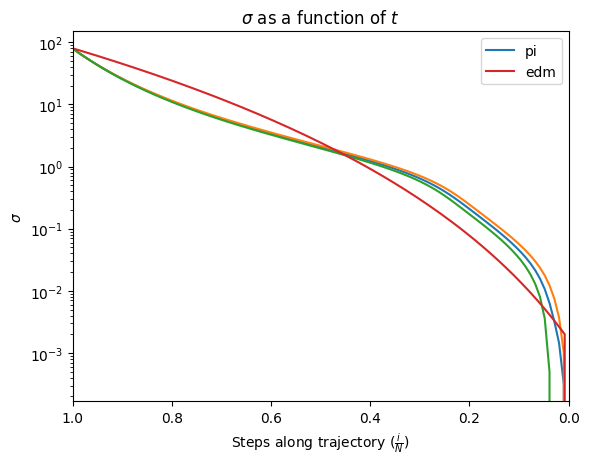

In [74]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas), label="pi")

plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="edm")


plt.legend()
plt.xlim(1, 0)
plt.xlabel(r"Steps along trajectory ($\frac{i}{N}$)")
plt.ylabel(r"$\sigma$")
plt.yscale("log")